In [60]:
# Importation des librairies
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [84]:

vacsi_s_dep=pd.read_csv('sexe/vacsi-s-dep-2023-07-13-15h51.csv',sep=';')

vacsi_a_dep=pd.read_csv('age/vacsi-a-dep-2023-07-13-15h50.csv',sep=';')

vacsi_v_dep=pd.read_csv('vaccin/vacsi-v-dep-2023-07-13-15h51.csv',sep=';')





C:\Users\Bilel\AppData\Local\Temp\ipykernel_19276\2520592473.py:1: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.

C:\Users\Bilel\AppData\Local\Temp\ipykernel_19276\2520592473.py:3: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.

C:\Users\Bilel\AppData\Local\Temp\ipykernel_19276\2520592473.py:5: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



In [62]:
vacsi_s_dep.columns

Index(['dep', 'sexe', 'jour', 'n_dose1', 'n_complet', 'n_rappel', 'n_2_rappel',
       'n_rappel_biv', 'n_3_rappel', 'n_cum_dose1', 'n_cum_complet',
       'n_cum_rappel', 'n_cum_2_rappel', 'n_cum_rappel_biv', 'n_cum_3_rappel',
       'couv_dose1', 'couv_complet', 'couv_rappel', 'couv_2_rappel',
       'couv_rappel_biv', 'couv_3_rappel'],
      dtype='object')

In [63]:
vacsi_v_dep.columns

Index(['dep', 'vaccin', 'jour', 'n_dose1', 'n_dose2', 'n_dose3', 'n_dose4',
       'n_complet', 'n_rappel', 'n_2_rappel', 'n_rappel_biv', 'n_3_rappel',
       'n_cum_dose1', 'n_cum_dose2', 'n_cum_dose3', 'n_cum_dose4',
       'n_cum_complet', 'n_cum_rappel', 'n_cum_2_rappel', 'n_cum_rappel_biv',
       'n_cum_3_rappel'],
      dtype='object')

In [64]:
vacsi_a_dep.columns

Index(['dep', 'clage_vacsi', 'jour', 'n_dose1', 'n_complet', 'n_rappel',
       'n_2_rappel', 'n_rappel_biv', 'n_3_rappel', 'n_cum_dose1',
       'n_cum_complet', 'n_cum_rappel', 'n_cum_2_rappel', 'n_cum_rappel_biv',
       'n_cum_3_rappel', 'couv_dose1', 'couv_complet', 'couv_rappel',
       'couv_2_rappel', 'couv_rappel_biv', 'couv_3_rappel'],
      dtype='object')

In [65]:
# Pour Dataframe vacsi_a_dep ('vacsi-s-dep-2023-07-13-15h51.csv')
# Target : n_totale_dose = n_dose1 + n_rappel + n_2_rappel + n_3_rappel + n_rappel_biv + n_complet
# Features : ['dep', 
#             'clage_vacsi', 
#             'jour', 
#             'couv_dose1_j-1', 
#             'couv_complet_j-1', 
#             'couv_rappel_j-1', 
#             'couv_2_rappel_j-1', 
#             'couv_rappel_biv_j-1', 
#             'couv_3_rappel_j-1'] => on doit prouver la correlation
# NB : les 'n_cum_xxx' sont équivalent aux 'couv_xxx' => on peut travailler sur l'un des 2 
# NB : n_cum_j-1 = n_cum - target
# NB : couv_dose1_j-1 = couv_dose1 - (n_dose1/population) => même règle pour le reste des taux de couvertures
vacsi_a_dep.loc[(vacsi_a_dep['n_complet'] != 0) & (vacsi_a_dep['n_dose1'] == 0)].head()



,dep,clage_vacsi,jour,n_dose1,n_complet,n_rappel,n_2_rappel,n_rappel_biv,n_3_rappel,n_cum_dose1,...,n_cum_rappel,n_cum_2_rappel,n_cum_rappel_biv,n_cum_3_rappel,couv_dose1,couv_complet,couv_rappel,couv_2_rappel,couv_rappel_biv,couv_3_rappel
190,1,4,2021-07-05,0,1,0,0,0,0,9,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
321,1,4,2021-11-13,0,1,0,0,0,0,13,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
365,1,4,2021-12-27,0,1,0,0,0,0,13,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
393,1,4,2022-01-24,0,1,0,0,0,0,13,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1065,1,11,2021-05-15,0,1,0,0,0,0,4,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


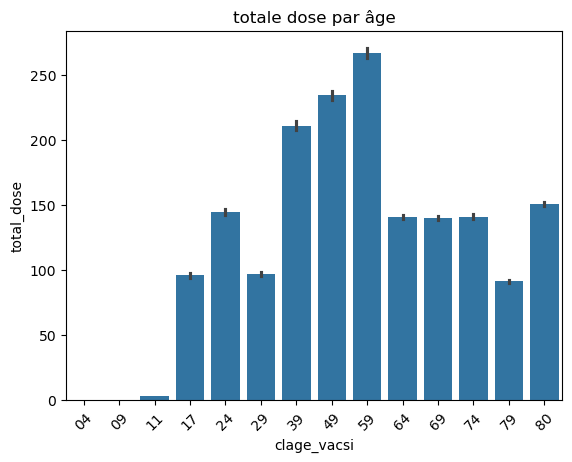

In [66]:
#relation age et nombre de dose de vaccin : 
vacsi_a_dep['total_dose']=vacsi_a_dep['n_dose1']+vacsi_a_dep['n_complet']+vacsi_a_dep['n_rappel']+vacsi_a_dep['n_2_rappel']+vacsi_a_dep['n_rappel_biv']+vacsi_a_dep['n_3_rappel']

ordre_age = ['04','09','11','17','24','29','39','49','59','64','69','74','79','80']

sns.barplot(
    x="clage_vacsi",
    y="total_dose",
    data=vacsi_a_dep[vacsi_a_dep["clage_vacsi"] != "0"],
    order=ordre_age
)

plt.xticks(rotation=45)
plt.title("totale dose par âge")
plt.show()

' On remarque que le nombre de doses dépend de l’âge, et que les tranches d’âge les plus vaccinées sont les 50–59 ans et les 80 ans et plus.'

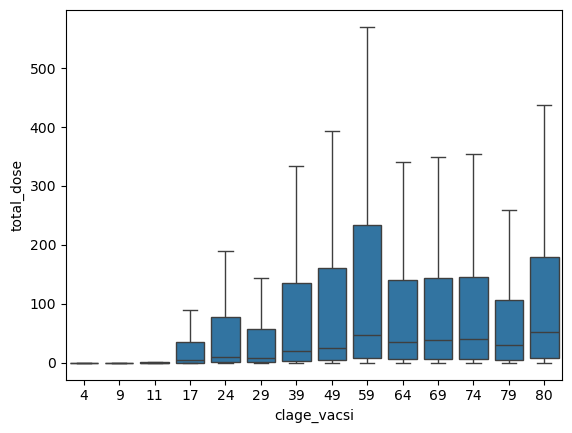

In [67]:
sns.boxplot(y="total_dose",x="clage_vacsi", data=vacsi_a_dep[vacsi_a_dep["clage_vacsi"] != 0], showfliers = False)
""" On remarque que le nombre de doses dépend de l’âge, et que les tranches d’âge les plus vaccinées sont les 50–59 ans et les 80 ans et plus."""

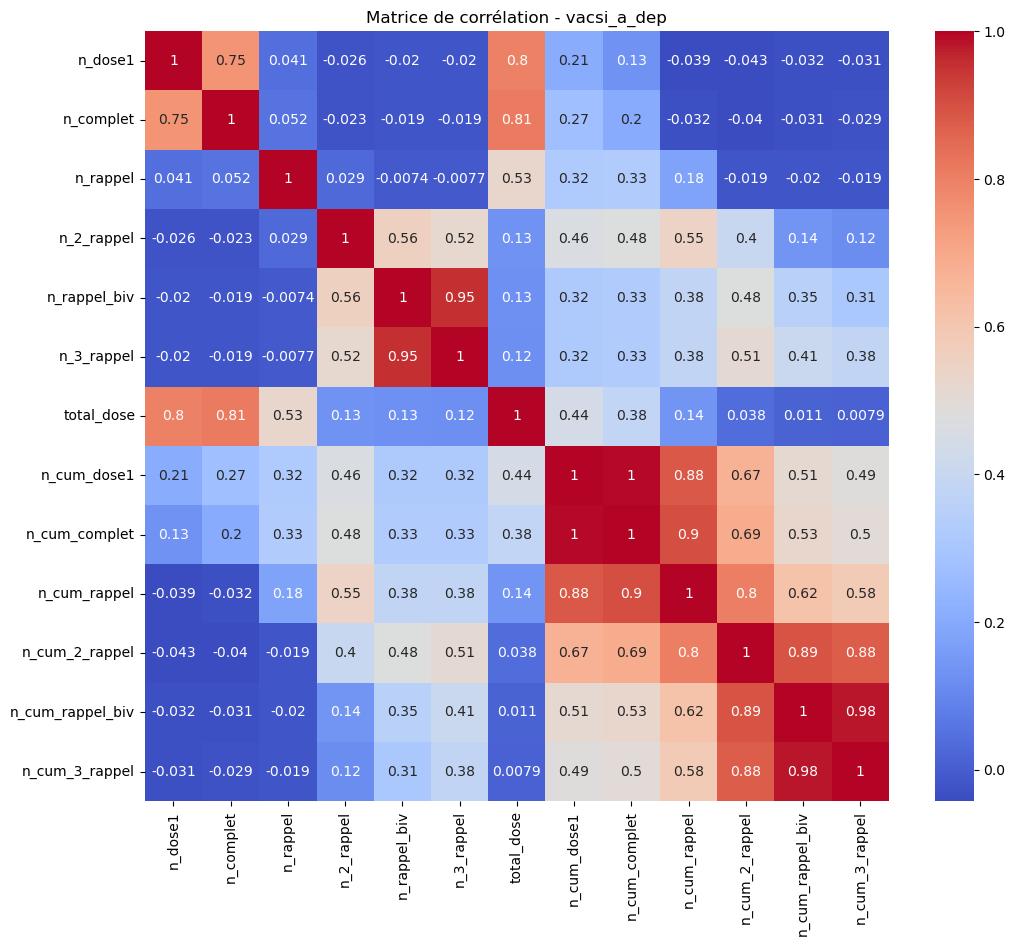

In [68]:
cols = [
    'n_dose1', 'n_complet', 'n_rappel',
       'n_2_rappel', 'n_rappel_biv', 'n_3_rappel',"total_dose" , 'n_cum_dose1',
       'n_cum_complet', 'n_cum_rappel', 'n_cum_2_rappel', 'n_cum_rappel_biv',
       'n_cum_3_rappel'
]

# Nettoyage des données
df_corr = vacsi_a_dep[cols].dropna()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")

plt.title("Matrice de corrélation - vacsi_a_dep")
plt.show()

In [69]:
# Pour Dataframe vacsi_s_dep ('vacsi-a-dep-2023-07-13-15h50.csv') : même concept que vacsi_a_dep
# De ma culture et d'après mon background, le sexe n'a aucun lien avec le nombre de vaccin => on doit prouver la non correlation
vacsi_s_dep

,dep,sexe,jour,n_dose1,n_complet,n_rappel,n_2_rappel,n_rappel_biv,n_3_rappel,n_cum_dose1,...,n_cum_rappel,n_cum_2_rappel,n_cum_rappel_biv,n_cum_3_rappel,couv_dose1,couv_complet,couv_rappel,couv_2_rappel,couv_rappel_biv,couv_3_rappel
0,1,1,2020-12-27,0,0,0,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,2020-12-28,0,0,0,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,2020-12-29,0,0,0,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,2020-12-30,0,0,0,0,0,0,0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,1,2020-12-31,1,0,0,0,0,0,1,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286129,978,0,2023-07-06,1,0,0,0,0,0,14856,...,6940,743,366,108,43.6,41.1,20.4,2.2,1.1,0.3
286130,978,0,2023-07-07,0,0,0,0,0,0,14856,...,6940,743,366,108,43.6,41.1,20.4,2.2,1.1,0.3
286131,978,0,2023-07-08,0,0,0,0,0,0,14856,...,6940,743,366,108,43.6,41.1,20.4,2.2,1.1,0.3
286132,978,0,2023-07-09,0,0,0,0,0,0,14856,...,6940,743,366,108,43.6,41.1,20.4,2.2,1.1,0.3


'Les médianes sont très proches Pas de différence évidente au niveau central Distributions similaires Variabilité comparable entre hommes et femmes'

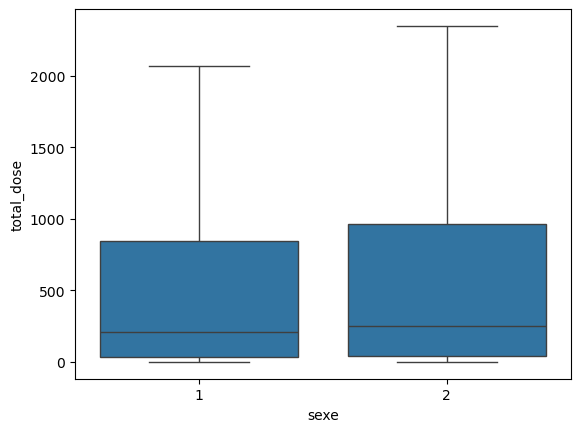

In [35]:
vacsi_s_dep['total_dose']=vacsi_s_dep['n_dose1']+vacsi_s_dep['n_complet']+vacsi_s_dep['n_rappel']+vacsi_s_dep['n_2_rappel']+vacsi_s_dep['n_rappel_biv']+vacsi_s_dep['n_3_rappel']
sns.boxplot(y="total_dose",x="sexe", data=vacsi_s_dep[vacsi_s_dep["sexe"] != 0], showfliers = False)
"""Les médianes sont très proches Pas de différence évidente au niveau central Distributions similaires Variabilité comparable entre hommes et femmes"""

" on remarque que le sexe n'influence pas sur le nombre de dose et donc cette variable a elimine  "

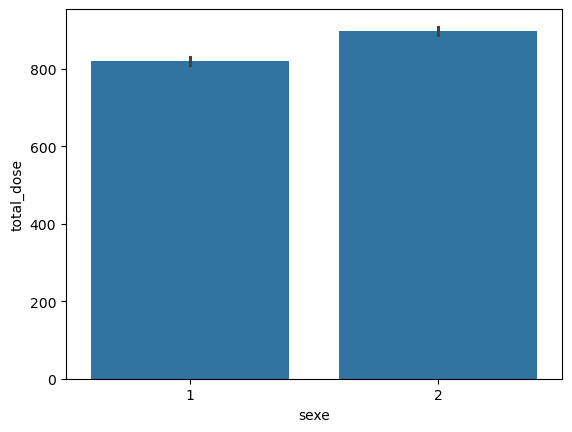

In [45]:
sns.barplot(x="sexe", y="total_dose", data=vacsi_s_dep[vacsi_s_dep["sexe"] != 0])
""" on remarque que le sexe n'influence pas sur le nombre de dose et donc cette variable a elimine  """


In [70]:
# Pour Dataframe vacsi_v_dep
# Target : n_totale_dose = n_dose1 + n_dose2 +	n_dose3	 + n_dose4	

vacsi_v_dep.loc[(vacsi_v_dep['n_complet'] != 0) & (vacsi_v_dep['n_dose1'] == 0) & (vacsi_v_dep['n_dose2'] == 0) & (vacsi_v_dep['n_dose3'] == 0)& (vacsi_v_dep['n_dose4'] == 0)].head() 


,dep,vaccin,jour,n_dose1,n_dose2,n_dose3,n_dose4,n_complet,n_rappel,n_2_rappel,...,n_3_rappel,n_cum_dose1,n_cum_dose2,n_cum_dose3,n_cum_dose4,n_cum_complet,n_cum_rappel,n_cum_2_rappel,n_cum_rappel_biv,n_cum_3_rappel


In [71]:
display(vacsi_v_dep.loc[(vacsi_v_dep['vaccin'] == 1) & (vacsi_v_dep['n_dose3'] == vacsi_v_dep['n_rappel']) & (vacsi_v_dep['n_dose3'] != 0)])

,dep,vaccin,jour,n_dose1,n_dose2,n_dose3,n_dose4,n_complet,n_rappel,n_2_rappel,...,n_3_rappel,n_cum_dose1,n_cum_dose2,n_cum_dose3,n_cum_dose4,n_cum_complet,n_cum_rappel,n_cum_2_rappel,n_cum_rappel_biv,n_cum_3_rappel
257,1,1,2021-09-10,873,1337,305,0,1485,305,0,...,0,380193,317867,3489,1,362243,2144,2,0,0
259,1,1,2021-09-12,35,69,4,0,73,4,0,...,0,380814,319170,3544,1,363643,2200,2,0,0
265,1,1,2021-09-18,308,1011,32,0,1074,32,0,...,0,383849,324918,5595,1,369835,4129,2,0,0
294,1,1,2021-10-17,8,15,2,0,15,2,0,...,0,390493,339915,14019,21,385434,12645,7,0,0
301,1,1,2021-10-24,3,12,3,0,14,3,0,...,0,391695,342355,17604,33,387701,16544,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039787,978,1,2023-03-22,1,0,1,0,0,1,0,...,0,13588,11952,6025,435,12891,6543,524,0,9
1039789,978,1,2023-03-24,0,0,1,0,0,1,0,...,0,13588,11952,6026,435,12891,6544,524,0,9
1039797,978,1,2023-04-01,0,0,1,0,0,1,0,...,0,13588,11952,6027,435,12891,6545,524,0,9
1039799,978,1,2023-04-03,0,0,1,0,0,1,0,...,0,13588,11952,6028,435,12891,6546,524,0,9


In [72]:

display(vacsi_v_dep.head())
print(vacsi_v_dep['dep'].unique())
vacsi_v_dep['jour']=pd.to_datetime(vacsi_v_dep['jour'])

vacsi_v_dep['dep']=vacsi_v_dep['dep'].astype('str') 
print(vacsi_v_dep['dep'].unique())
print(vacsi_v_dep.info())


,dep,vaccin,jour,n_dose1,n_dose2,n_dose3,n_dose4,n_complet,n_rappel,n_2_rappel,...,n_3_rappel,n_cum_dose1,n_cum_dose2,n_cum_dose3,n_cum_dose4,n_cum_complet,n_cum_rappel,n_cum_2_rappel,n_cum_rappel_biv,n_cum_3_rappel
0,1,1,2020-12-27,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,2020-12-28,1,0,0,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0
2,1,1,2020-12-29,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
3,1,1,2020-12-30,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
4,1,1,2020-12-31,1,0,0,0,0,0,0,...,0,2,0,0,0,1,0,0,0,0


[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26 27 '27'
 '28' '29' '2A' '2B' '30' '31' '32' 32 33 34 35 36 37 38 39 40 41 42 43 44
 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68
 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92
 93 94 95 971 972 973 974 976 977 978 '978' '01' '02' '03' '04' '05' '06'
 '07' '08' '09' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '21'
 '22' '23' '24' '25' '26' '33' '34']
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '21' '22' '23' '24' '25' '26' '27' '28' '29' '2A' '2B'
 '30' '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43'
 '44' '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57'
 '58' '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71'
 '72' '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84' '85'
 '86' '87' '88' '89' '90' '91' '92' '93' '94' '95' '971' '972' '973' '974'
 '976' '977' '978' '

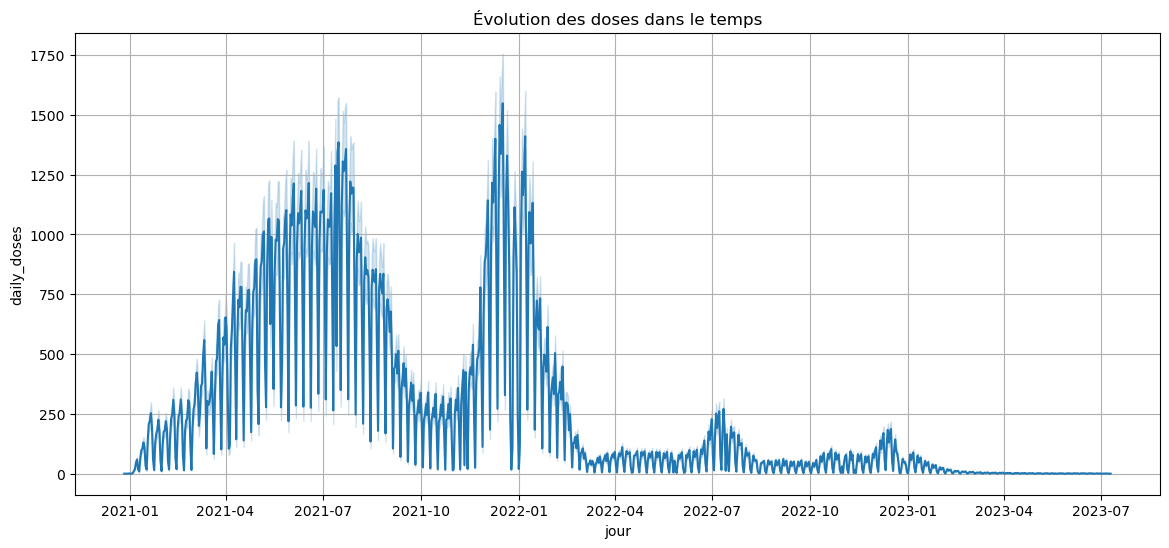

In [73]:
vacsi_v_dep["daily_doses"] = (
   vacsi_v_dep["n_dose1"] +
    vacsi_v_dep["n_dose2"] +
    vacsi_v_dep["n_dose3"] +
    vacsi_v_dep["n_dose4"]
)
plt.figure(figsize=(14,6))
sns.lineplot(data=vacsi_v_dep, x="jour", y="daily_doses")
plt.title("Évolution des doses dans le temps")
plt.grid()
plt.show()

' le graphique Montre : tendances pics (campagnes vaccinales  ) saisonnalité '

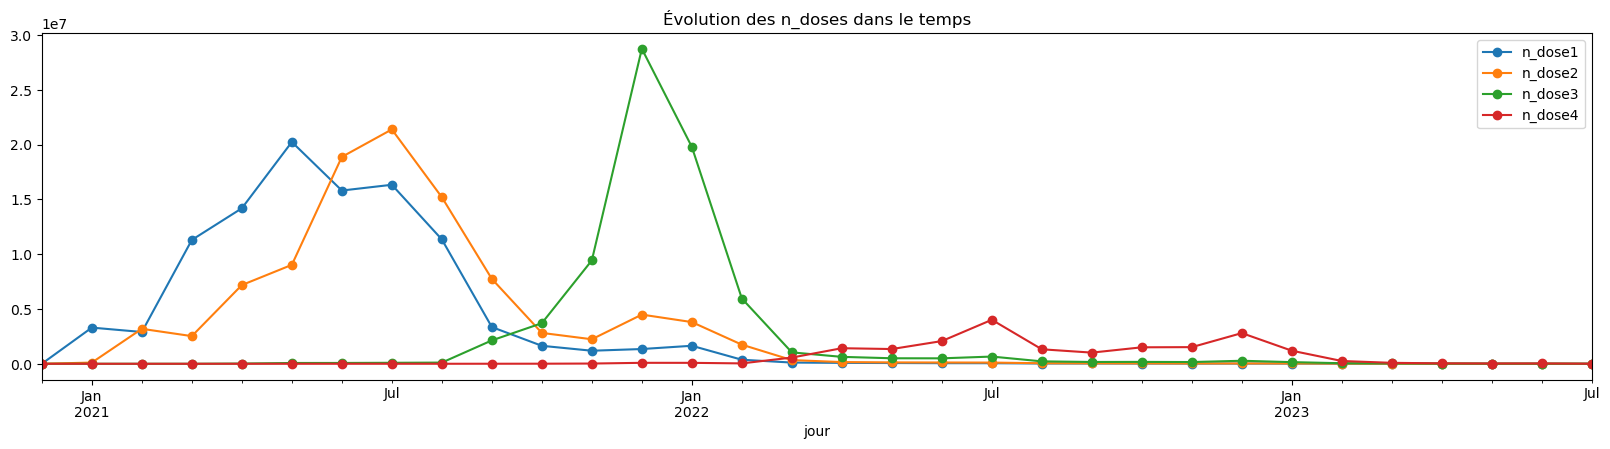

In [17]:
groups = vacsi_v_dep.groupby(by=[pd.Grouper(key = 'jour', freq = 'ME')]).agg({'n_dose1':'sum',\
                                                                              'n_dose2':'sum',\
                                                                              'n_dose3':'sum',\
                                                                              'n_dose4': 'sum'})
groups.plot(figsize = (20, 4.5), style = 'o-')
plt.title("Évolution des n_doses dans le temps") ;
""" le graphique Montre : tendances pics (campagnes vaccinales  ) saisonnalité """

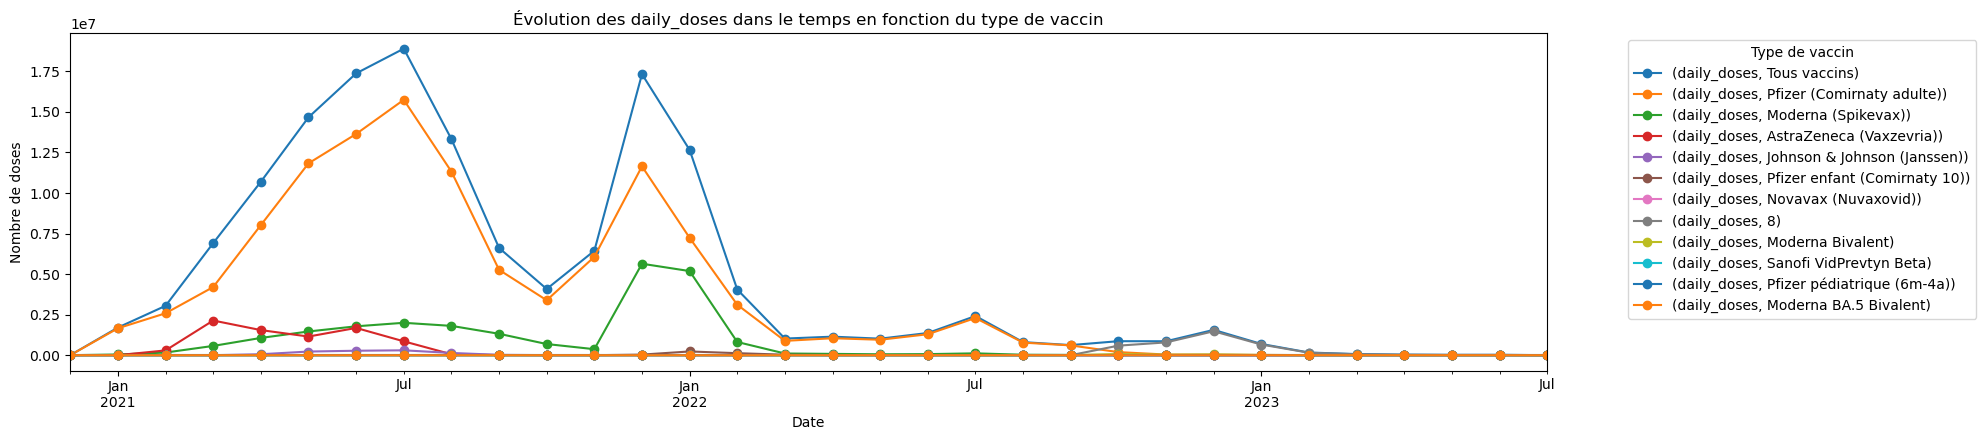

In [75]:
typ_vacc = vacsi_v_dep.groupby(by=[pd.Grouper(key = 'jour', freq = 'ME'),vacsi_v_dep["vaccin"]]).agg({"daily_doses":'sum'}).unstack()

# Renommer les colonnes avec les labels
vaccin_labels = {
    0: "Tous vaccins",
    1: "Pfizer (Comirnaty adulte)",
    2: "Moderna (Spikevax)",
    3: "AstraZeneca (Vaxzevria)",
    4: "Johnson & Johnson (Janssen)",
    5: "Pfizer enfant (Comirnaty 10)",
    6: "Novavax (Nuvaxovid)",
    9: "Moderna Bivalent",
    10: "Sanofi VidPrevtyn Beta",
    11: "Pfizer pédiatrique (6m-4a)",
    12: "Moderna BA.5 Bivalent"
}

typ_vacc = typ_vacc.rename(columns=vaccin_labels)

# Plot
ax = typ_vacc.plot(figsize=(20, 4.5), marker='o')

plt.title("Évolution des daily_doses dans le temps en fonction du type de vaccin")
plt.xlabel("Date")
plt.ylabel("Nombre de doses")

plt.legend(title="Type de vaccin", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

les 5 top departements Index(['59', '75', '13', '69', '33'], dtype='object', name='dep')


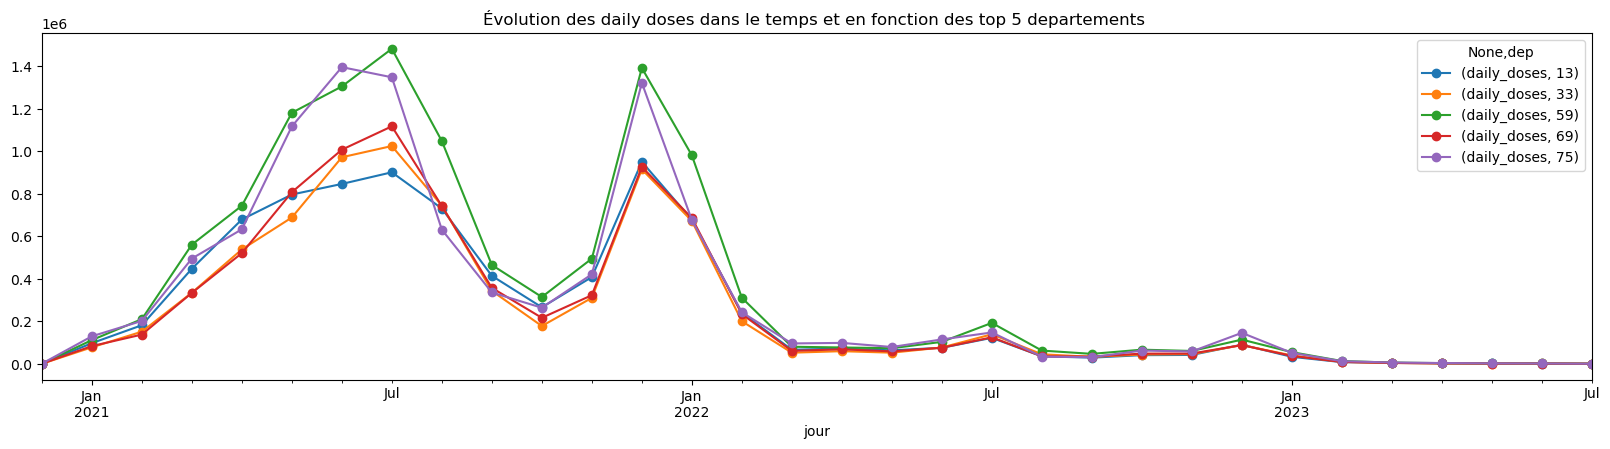

In [77]:
top_dep_index = vacsi_v_dep.groupby("dep")["daily_doses"].sum().nlargest(5).index
print('les 5 top departements',top_dep_index)
top_dep = vacsi_v_dep[vacsi_v_dep["dep"].isin(top_dep_index)]\
    .groupby(by=[pd.Grouper(key = 'jour', freq = 'ME'),vacsi_v_dep["dep"]])\
    .agg({"daily_doses":'sum'}).unstack()
top_dep.plot(figsize = (20, 4.5), style = 'o-')
plt.title("Évolution des daily doses dans le temps et en fonction des top 5 departements ") ;

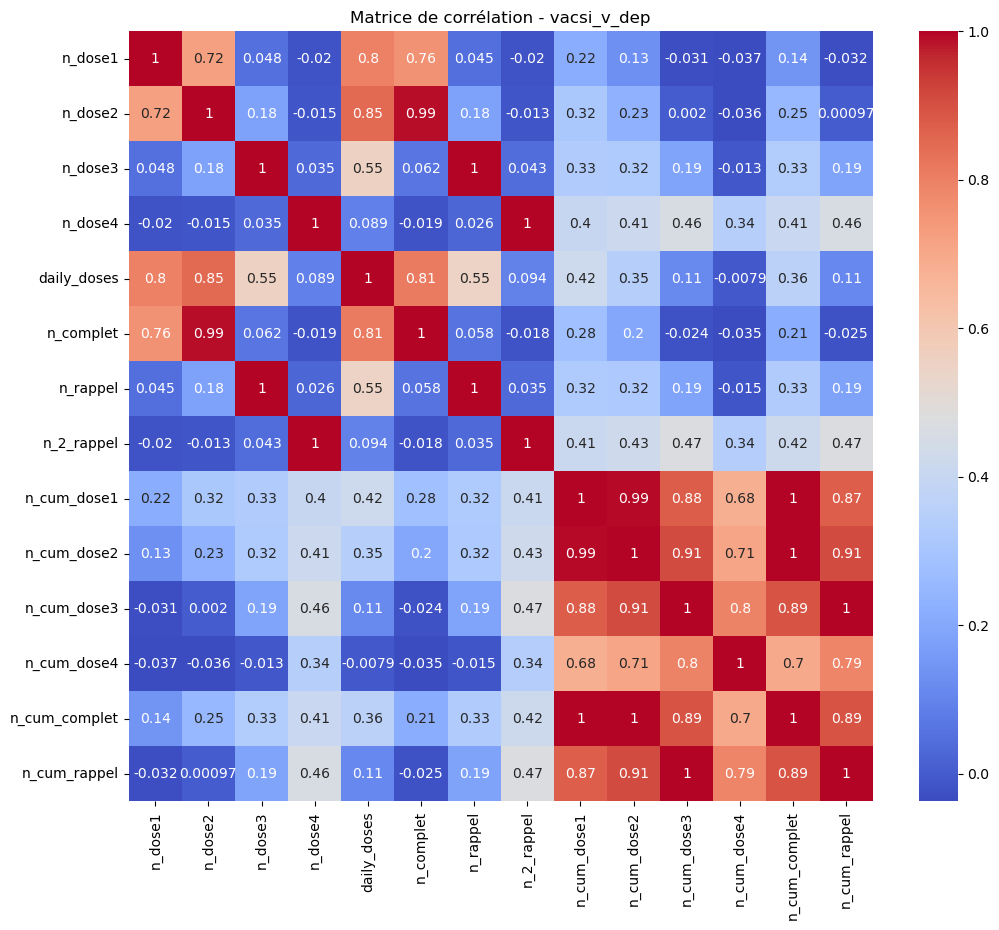

In [78]:
# Colonnes pertinentes pour la corrélation
cols = [
    'n_dose1', 'n_dose2', 'n_dose3', 'n_dose4','daily_doses',
    'n_complet', 'n_rappel', 'n_2_rappel',
    'n_cum_dose1', 'n_cum_dose2', 'n_cum_dose3', 'n_cum_dose4',
    'n_cum_complet', 'n_cum_rappel',
]

# Nettoyage des données
df_corr = vacsi_v_dep[cols].dropna()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm")

plt.title("Matrice de corrélation - vacsi_v_dep")
plt.show()

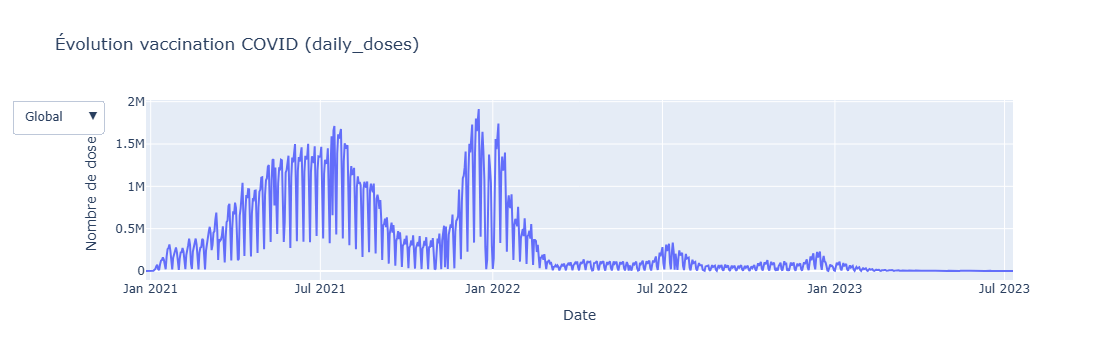

In [83]:
import pandas as pd
import plotly.graph_objects as go

def plot_interactive(data):


    # ===== GLOBAL =====
    global_data = data.groupby("jour")["daily_doses"].sum().reset_index()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=global_data["jour"],
        y=global_data["daily_doses"],
        mode="lines",
        name="Global",
        visible=True
    ))

    # ===== PAR DÉPARTEMENT =====
    deps = data["dep"].unique()

    for dep in deps:
        df_dep = data[data["dep"] == dep]
        df_dep = df_dep.groupby("jour")["daily_doses"].sum().reset_index()

        fig.add_trace(go.Scatter(
            x=df_dep["jour"],
            y=df_dep["daily_doses"],
            mode="lines",
            name=f"Dep {dep}",
            visible=False
        ))

    # ===== BOUTONS =====
    buttons = []

    # Bouton Global
    buttons.append(dict(
        label="Global",
        method="update",
        args=[{"visible": [True] + [False] * len(deps)}]
    ))

    # Boutons départements
    for i, dep in enumerate(deps):
        visible = [False] * (len(deps) + 1)
        visible[i + 1] = True

        buttons.append(dict(
            label=f"Dep {dep}",
            method="update",
            args=[{"visible": visible}]
        ))

    # ===== MENU =====
    fig.update_layout(
        title="Évolution vaccination COVID (daily_doses)",
        xaxis_title="Date",
        yaxis_title="Nombre de doses",
        updatemenus=[
            dict(
                active=0,
                buttons=buttons
            )
        ]
    )

    fig.show()
plot_interactive(vacsi_v_dep)

In [ ]:
d